# Module 2 — Baseline CNN (Scratch)
3-layer CNN trained from scratch. Sets performance floor for comparison with transfer learning.

In [1]:
import json, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR  = Path(r'C:\Users\harsh\satellite_project')
DATA_DIR  = BASE_DIR / 'data' / 'split'
PLOTS_DIR = BASE_DIR / 'outputs' / 'plots'
CKPT_DIR  = BASE_DIR / 'outputs' / 'checkpoints'
SRC_DIR   = BASE_DIR / 'src'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

with open(SRC_DIR / 'class_names.json') as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {NUM_CLASSES} → {CLASS_NAMES}')

Device: cpu
Classes: 10 → ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
# ── DataLoaders ─────────────────────────────────────────────────────────────
IMG_SIZE = 64
BATCH    = 64

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(DATA_DIR / 'train', transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_DIR / 'val',   transform=val_tf)
test_ds  = datasets.ImageFolder(DATA_DIR / 'test',  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 18900 | Val: 4050 | Test: 4050


In [3]:
# ── 3-Layer Scratch CNN ──────────────────────────────────────────────────────
class BaselineCNN(nn.Module):
    """Simple 3-block CNN trained from scratch (performance floor)."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3→32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 64→32

            # Block 2: 32→64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 32→16

            # Block 3: 64→128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 16→8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 2,193,674
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=

In [4]:
# ── Training loop ────────────────────────────────────────────────────────────
EPOCHS    = 20
LR        = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0.0

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);    val_accs.append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CKPT_DIR / 'baseline_best.pt')

    print(f'Ep {epoch:02d}/{EPOCHS} | '
          f'Loss {tr_loss:.4f}/{va_loss:.4f} | '
          f'Acc {tr_acc:.4f}/{va_acc:.4f} | '
          f'{time.time()-t0:.1f}s')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Ep 01/20 | Loss 1.2719/0.9874 | Acc 0.5604/0.6484 | 697.2s
Ep 02/20 | Loss 0.8761/0.6565 | Acc 0.6955/0.7605 | 149.2s
Ep 03/20 | Loss 0.7792/0.5453 | Acc 0.7270/0.8064 | 119.0s
Ep 04/20 | Loss 0.7155/0.8187 | Acc 0.7550/0.7259 | 119.2s
Ep 05/20 | Loss 0.6644/0.4538 | Acc 0.7732/0.8477 | 197.7s
Ep 06/20 | Loss 0.6042/0.5236 | Acc 0.7962/0.8202 | 227.2s
Ep 07/20 | Loss 0.5540/0.4382 | Acc 0.8129/0.8422 | 314.9s
Ep 08/20 | Loss 0.5201/0.7172 | Acc 0.8276/0.7674 | 130.6s
Ep 09/20 | Loss 0.4776/0.3956 | Acc 0.8437/0.8672 | 143.2s
Ep 10/20 | Loss 0.4335/0.3321 | Acc 0.8571/0.8889 | 250.5s
Ep 11/20 | Loss 0.4056/0.3050 | Acc 0.8684/0.9002 | 235.0s
Ep 12/20 | Loss 0.3615/0.3411 | Acc 0.8808/0.8837 | 200.2s
Ep 13/20 | Loss 0.3416/0.2727 | Acc 0.8892/0.9101 | 183.0s
Ep 14/20 | Loss 0.3076/0.6348 | Acc 0.9001/0.8277 | 171.8s
Ep 15/20 | Loss 0.2902/0.2666 | Acc 0.9046/0.9096 | 170.6s
Ep 16/20 | Loss 0.2732/0.2321 | Acc 0.9103/0.9262 | 174.1s
Ep 17/20 | Loss 0.2518/0.2020 | Acc 0.9178/0.9333 | 172.

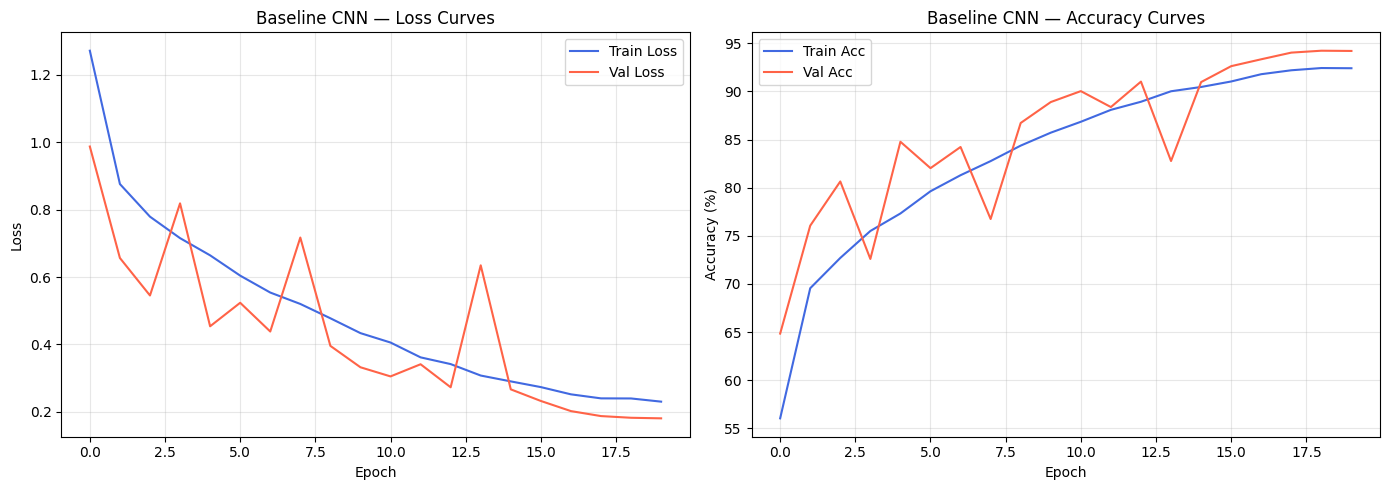

In [5]:
# ── Loss & Accuracy Curves ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='royalblue')
ax1.plot(val_losses,   label='Val Loss',   color='tomato')
ax1.set_title('Baseline CNN — Loss Curves')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot([a*100 for a in train_accs], label='Train Acc', color='royalblue')
ax2.plot([a*100 for a in val_accs],   label='Val Acc',   color='tomato')
ax2.set_title('Baseline CNN — Accuracy Curves')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_cnn_curves.png', dpi=100)
plt.show()

In [6]:
# ── Evaluate on Test Set ─────────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_DIR / 'baseline_best.pt', map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('=== Baseline CNN — Test Set Report ===')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f'Macro-F1: {macro_f1:.4f}')

=== Baseline CNN — Test Set Report ===
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.93      0.94       450
              Forest       0.98      0.98      0.98       450
HerbaceousVegetation       0.89      0.91      0.90       450
             Highway       0.89      0.87      0.88       375
          Industrial       0.94      0.97      0.95       375
             Pasture       0.90      0.93      0.92       300
       PermanentCrop       0.91      0.88      0.89       375
         Residential       0.99      0.98      0.98       450
               River       0.89      0.87      0.88       375
             SeaLake       0.98      0.99      0.98       450

            accuracy                           0.93      4050
           macro avg       0.93      0.93      0.93      4050
        weighted avg       0.93      0.93      0.93      4050

Macro-F1: 0.9305


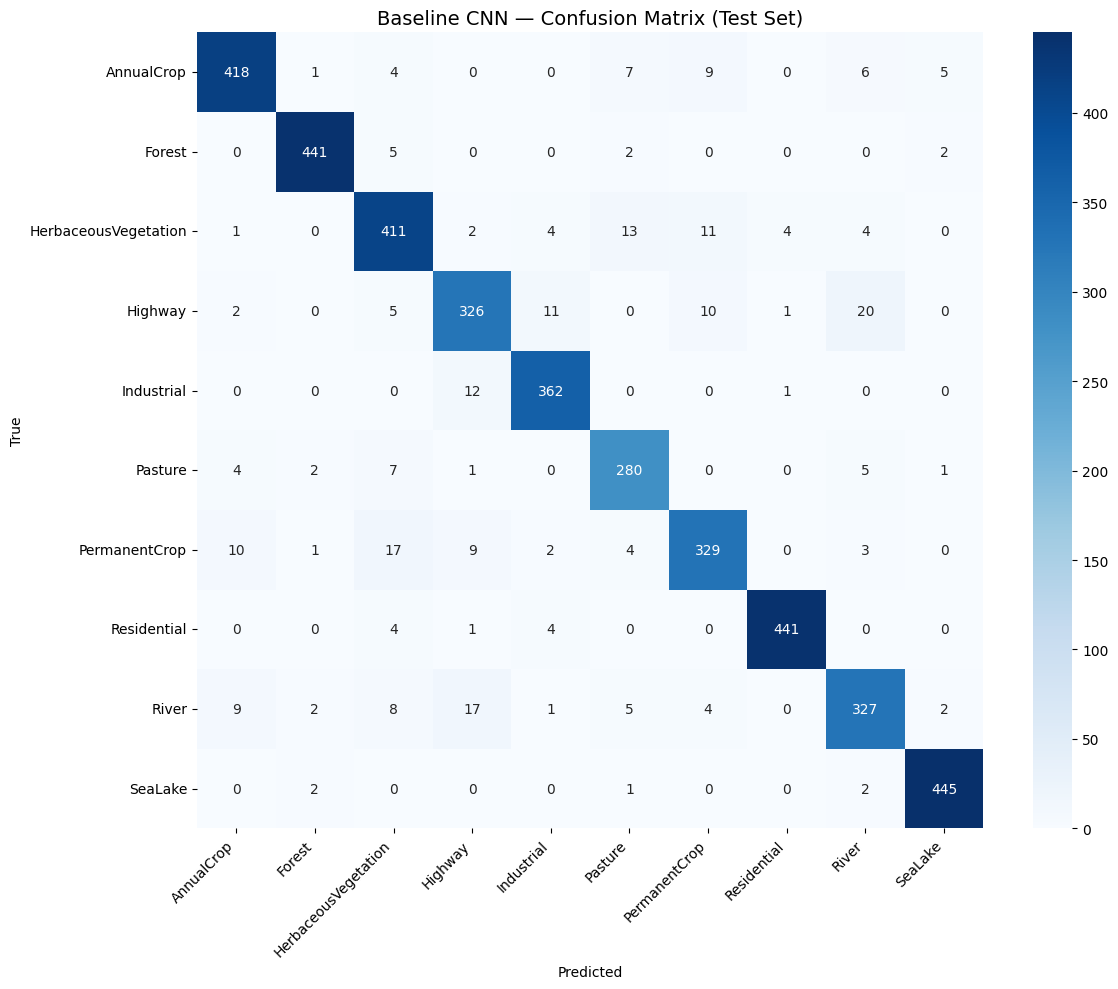

In [7]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Baseline CNN — Confusion Matrix (Test Set)', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_confusion_matrix.png', dpi=100)
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_1804\92067451.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')


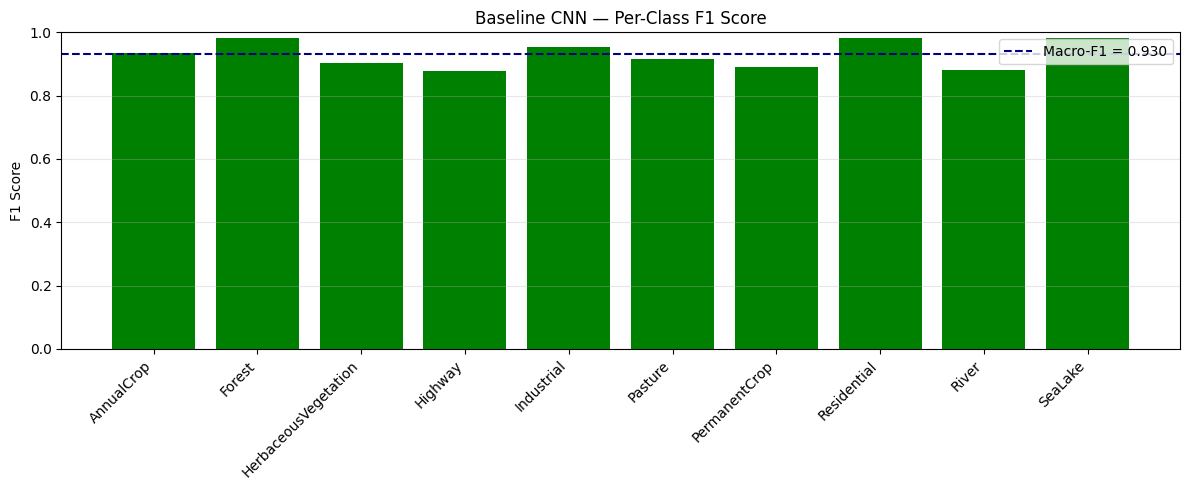

Baseline CNN results saved. This is the performance FLOOR.
Macro-F1 to beat: 0.9305


In [8]:
# ── Per-class F1 Bar Chart ───────────────────────────────────────────────────
per_class_f1 = f1_score(all_labels, all_preds, average=None)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['green' if f > 0.7 else 'orange' if f > 0.5 else 'red' for f in per_class_f1]
ax.bar(CLASS_NAMES, per_class_f1, color=colors)
ax.axhline(macro_f1, color='navy', linestyle='--', label=f'Macro-F1 = {macro_f1:.3f}')
ax.set_title('Baseline CNN — Per-Class F1 Score')
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.0)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_per_class_f1.png', dpi=100)
plt.show()

print('Baseline CNN results saved. This is the performance FLOOR.')
print(f'Macro-F1 to beat: {macro_f1:.4f}')